In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [24]:
# Load dataset
data = pd.read_csv("Students Performance .csv")

In [25]:
# Preview data
print("First 5 rows:")
print(data.head())

print("\nShape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

print("\nGrade counts:")
print(data["Grade"].value_counts())


First 5 rows:
  Student_ID Student_Age     Sex High_School_Type Scholarship Additional_Work  \
0   STUDENT1       19-22    Male            Other         50%             Yes   
1   STUDENT2       19-22    Male            Other         50%             Yes   
2   STUDENT3       19-22    Male            State         50%              No   
3   STUDENT4          18  Female          Private         50%             Yes   
4   STUDENT5       19-22    Male          Private         50%              No   

  Sports_activity Transportation  Weekly_Study_Hours Attendance Reading Notes  \
0              No        Private                   0     Always     Yes   Yes   
1              No        Private                   0     Always     Yes    No   
2              No        Private                   2      Never      No    No   
3              No            Bus                   2     Always      No   Yes   
4              No            Bus                  12     Always     Yes    No   

  Listening_

In [26]:
# Fill missing value in Scholarship with the most common value
data["Scholarship"] = data["Scholarship"].fillna(data["Scholarship"].mode()[0])

# Create pass/fail target
data["Pass"] = data["Grade"].apply(lambda x: 0 if x == "Fail" else 1)
print(data["Pass"].value_counts())

print("\nPass/Fail counts:")
print(data["Pass"].value_counts())

# Drop ID and original grade column
X = data.drop(columns=["Student_ID", "Grade", "Pass"])
y = data["Pass"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

print("\nEncoded feature columns:")
print(X.columns)


Pass
1    137
0      8
Name: count, dtype: int64

Pass/Fail counts:
Pass
1    137
0      8
Name: count, dtype: int64

Encoded feature columns:
Index(['Weekly_Study_Hours', 'Student_Age_19-22', 'Student_Age_23-27',
       'Sex_Male', 'High_School_Type_Private', 'High_School_Type_State',
       'Scholarship_25%', 'Scholarship_50%', 'Scholarship_75%',
       'Additional_Work_Yes', 'Sports_activity_Yes', 'Transportation_Private',
       'Attendance_Always', 'Attendance_Never', 'Attendance_Sometimes',
       'Reading_Yes', 'Notes_No', 'Notes_Yes', 'Listening_in_Class_No',
       'Listening_in_Class_Yes', 'Project_work_Yes'],
      dtype='str')


In [27]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
# Train model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [29]:
# Make predictions
predictions = model.predict(X_test)

# Evaluate model
print("\nAccuracy:")
print(accuracy_score(y_test, predictions))

print("Error rate:", 1 - accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# Compare true labels and predicted labels on the test set
print("\nTrue labels in y_test:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nPredicted labels:")
print(pd.Series(predictions).value_counts().sort_index())

print("\nNumber of mismatches:", (pd.Series(y_test).reset_index(drop=True) != pd.Series(predictions)).sum())

# Diagnostic table with probabilities
try:
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test)[:, 1]
        cmp = pd.DataFrame({
            'y_true': y_test.reset_index(drop=True),
            'y_pred': pd.Series(predictions),
            'prob_pos': probs
        })
        mismatches_df = cmp[cmp['y_true'] != cmp['y_pred']]
        print('\nMismatches detail (test rows where prediction != true):')
        display(mismatches_df.reset_index(drop=True))
    else:
        print('\nModel has no predict_proba; skipping probability diagnostics.')
except Exception as e:
    print('Diagnostic generation failed:', e)


Accuracy:
0.896551724137931
Error rate: 0.10344827586206895

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.96      0.93      0.94        27

    accuracy                           0.90        29
   macro avg       0.65      0.71      0.67        29
weighted avg       0.92      0.90      0.91        29


Confusion Matrix:
[[ 1  1]
 [ 2 25]]

True labels in y_test:
Pass
0     2
1    27
Name: count, dtype: int64

Predicted labels:
0     3
1    26
Name: count, dtype: int64

Number of mismatches: 3

Mismatches detail (test rows where prediction != true):


,y_true,y_pred,prob_pos
0,1,0,0.026549
1,1,0,0.051724
2,0,1,1.000000


Sex_Male                    0.501728
High_School_Type_Private    0.230998
Attendance_Always           0.137399
Scholarship_75%             0.080488
Reading_Yes                 0.030571
Transportation_Private      0.018815
Student_Age_19-22           0.000000
Weekly_Study_Hours          0.000000
Student_Age_23-27           0.000000
Scholarship_50%             0.000000
dtype: float64


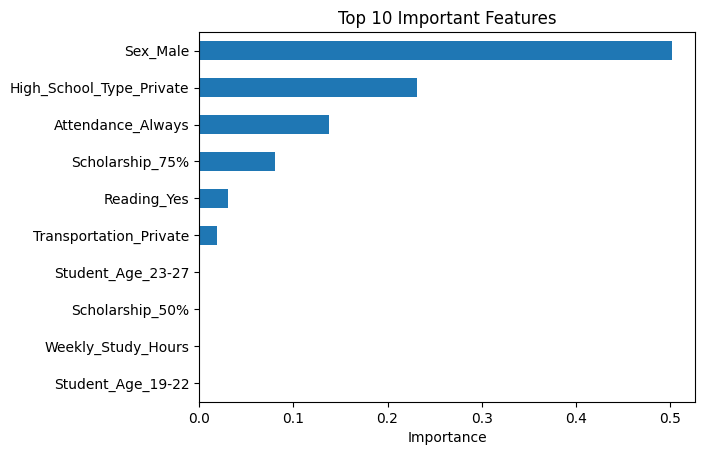

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

print(top_features)

top_features.sort_values().plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()